### 导入依赖库与数据读取

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# ==========================================# 1. 数据装载 # ==========================================#
df_cpu = pd.read_csv("/Users/macbookpro/Desktop/Project/软件测试与维护/大作业/jiaoben/20用户/整体总负载与整体平均CPU使用率-data-as-joinbyfield-2026-06-14 18_23_11.csv")
df_net_bw = pd.read_csv("/Users/macbookpro/Desktop/Project/软件测试与维护/大作业/jiaoben/20用户/每秒网络带宽使用eth0-data-as-joinbyfield-2026-06-14 18_22_24.csv")
df_socket = pd.read_csv("/Users/macbookpro/Desktop/Project/软件测试与维护/大作业/jiaoben/20用户/网络Socket连接信息-data-as-joinbyfield-2026-06-14 18_22_05.csv") 

### 多维特征按时间对齐与拼接

In [23]:
# ==========================================# 2. 特征融合 (Feature Fusion)# ==========================================#
df_cpu['Time'] = pd.to_datetime(df_cpu['Time'])
df_net_bw['Time'] = pd.to_datetime(df_net_bw['Time'])
df_socket['Time'] = pd.to_datetime(df_socket['Time'])

# 按照 Time 列进行内连接合并
df_merged = pd.merge(df_cpu, df_net_bw, on="Time")
df_merged = pd.merge(df_merged, df_socket, on="Time")

print("多维特征拼接完成！当前的特征矩阵维度为:", df_merged.shape)

多维特征拼接完成！当前的特征矩阵维度为: (69, 14)


### 严格对齐时间轴打标签

In [24]:
df_merged['label'] = 0
poison_start = pd.to_datetime("2026-06-14 18:04:00")
poison_end = pd.to_datetime("2026-06-14 18:14:00")

df_merged.loc[(df_merged['Time'] >= poison_start) & (df_merged['Time'] <= poison_end), 'label'] = 1

print("正常 vs 异常样本分布:\n", df_merged['label'].value_counts())

正常 vs 异常样本分布:
 label
0    48
1    21
Name: count, dtype: int64


### 清洗数据

In [25]:
def clean_all_units(val):
    if pd.isna(val):
        return 0.0
    
    val_str = str(val).strip().lower()
    try:
        for suffix in ['kb/s', 'mb/s', 'b/s', 'kb', 'mb', 'b', '/s', 's', '%']:
            val_str = val_str.replace(suffix, '')
        
        if val_str.endswith('m'):
            val_str = val_str[:-1].strip()
            
        if not val_str:
            return 0.0
            
        pure_num = float(val_str)
        
        # 针对大流量网络带宽的换算
        original_val = str(val).lower()
        if 'm' in original_val and 'mb' in original_val:
            return pure_num * 1024.0
        elif 'b' in original_val and 'k' not in original_val:
            return pure_num / 1024.0
            
        return pure_num
    except:
        return 0.0

### 提取特征

In [26]:
features = [col for col in df_merged.columns if col not in ['Time', 'label']]
for col in features:
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].apply(clean_all_units)

print("所有特征列的单位（包括 kb/s、%）已全部清洗完毕")

X = df_merged[features]
y = df_merged['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

所有特征列的单位（包括 kb/s、%）已全部清洗完毕


### 训练模型与预测

In [27]:
# ==========================================# 5. 孤立森林模型训练与预测# ==========================================#
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print(f"正在为20用户极端高并发场景训练【随机森林】分类器...")

rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1] # 获取异常概率

print("\n 20用户场景随机森林评估报告:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

# 计算 AUC 得分
auc_score = roc_auc_score(y_test, y_prob)
print(f"20用户级联场景下，有监督 AUC 核心得分: {auc_score:.4f}")

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
print("\n 20用户场景下多维指标贡献度前5名:")
for f in range(min(5, X.shape[1])):
    print(f"{f + 1}. 特征 [{features[indices[f]]}] 贡献度: {importances[indices[f]]:.4f}")

正在为20用户极端高并发场景训练【随机森林】分类器...

 20用户场景随机森林评估报告:
              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97        15
     Anomaly       1.00      0.83      0.91         6

    accuracy                           0.95        21
   macro avg       0.97      0.92      0.94        21
weighted avg       0.96      0.95      0.95        21

20用户级联场景下，有监督 AUC 核心得分: 0.9889

 20用户场景下多维指标贡献度前5名:
1. 特征 [平均%] 贡献度: 0.1619
2. 特征 [eth0_in下载] 贡献度: 0.1388
3. 特征 [TCP_alloc] 贡献度: 0.1357
4. 特征 [eth0_out上传] 贡献度: 0.1161
5. 特征 [Tcp_OutSegs] 贡献度: 0.1150


### 输出指标并画图


20用户场景随机森林评估报告:
              precision    recall  f1-score   support

      Normal       0.94      1.00      0.97        15
     Anomaly       1.00      0.83      0.91         6

    accuracy                           0.95        21
   macro avg       0.97      0.92      0.94        21
weighted avg       0.96      0.95      0.95        21

20用户级联场景下，有监督 AUC 核心得分: 0.9889
正在为 20 用户场景生成专属时序概率图...
专属时序概率图已保存至本地: random_forest_20users_report.png


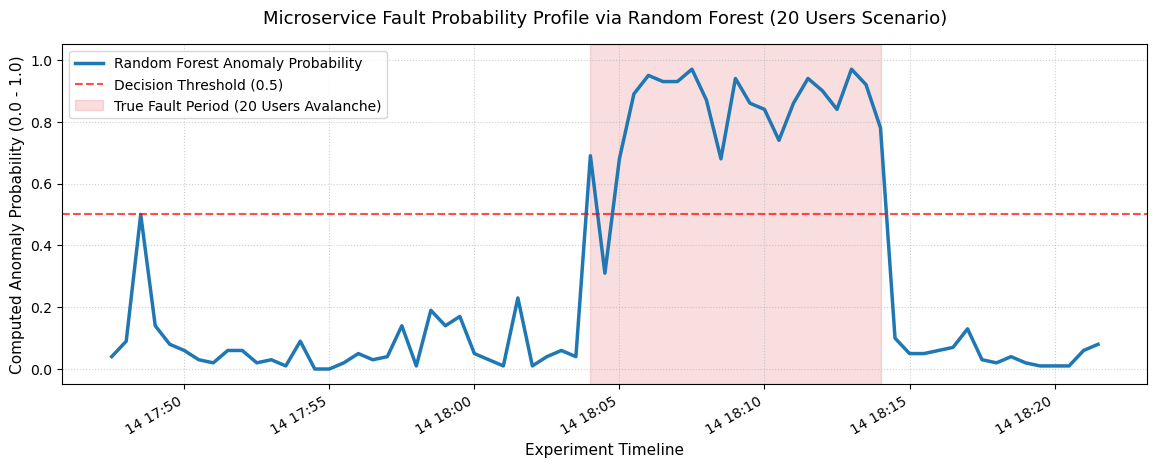

In [28]:
# ==========================================# 6. 成果输出与评估 # ==========================================
from sklearn.metrics import classification_report, roc_auc_score

print("\n20用户场景随机森林评估报告:")

print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

# 计算 AUC 得分
auc_score = roc_auc_score(y_test, y_prob)
print(f"20用户级联场景下，有监督 AUC 核心得分: {auc_score:.4f}")

import matplotlib.pyplot as plt

print("正在为 20 用户场景生成专属时序概率图...")

test_indices = np.sort(X_test.index if hasattr(X_test, 'index') else range(len(y_test)))
df_test_sorted = df_merged.iloc[test_indices].sort_values('Time')

df_merged['anomaly_prob'] = rf_model.predict_proba(X_scaled)[:, 1]

plt.figure(figsize=(14, 5))
plt.plot(df_merged['Time'], df_merged['anomaly_prob'], 
         label='Random Forest Anomaly Probability', color='#1f77b4', lw=2.5)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Decision Threshold (0.5)')
plt.axvspan(poison_start, poison_end, color='#d62728', alpha=0.15, label='True Fault Period (20 Users Avalanche)')
plt.title("Microservice Fault Probability Profile via Random Forest (20 Users Scenario)", fontsize=13, pad=15)
plt.xlabel("Experiment Timeline", fontsize=11)
plt.ylabel("Computed Anomaly Probability (0.0 - 1.0)", fontsize=11)
plt.ylim(-0.05, 1.05) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc="upper left", fontsize=10)
plt.gcf().autofmt_xdate()

output_img_name = "random_forest_20users_report.png"
plt.savefig(output_img_name, dpi=300, bbox_inches='tight')
print(f"专属时序概率图已保存至本地: {output_img_name}")
plt.show()